# Corpus Analysis: Cranfield vs MEDLINE

Notebook này tổng hợp cả hai lớp phân tích:

1. **Analyze riêng từng corpus**: Cranfield và MEDLINE.
2. **Comparison giữa hai corpus**: kích thước, độ dài văn bản, vocabulary, TF/DF/IDF, query-document overlap và relevance structure.

Mục tiêu của notebook là phục vụ kịch bản đồ án: so sánh các mô hình IR cổ điển như TF-IDF, BM25, LSA trên các corpus có đặc trưng khác nhau, nhưng **không finetune tham số mô hình**.

## 0. Setup

Bạn chỉ cần chỉnh các đường dẫn ở cell cấu hình bên dưới. Notebook này giả định mỗi corpus có 3 file:

- `documents.csv`
- `queries.csv`
- `qrels.csv`

Nếu tên cột khác nhau, chỉnh mapping trong `CORPUS_CONFIGS`.

In [59]:
from pathlib import Path
from collections import Counter, defaultdict
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [60]:
# ============================================================
# CONFIG: chỉnh lại path và tên cột theo dữ liệu local của bạn
# ============================================================

CORPUS_CONFIGS = {
    "cranfield": {
        "documents_path": r"C:\Users\ADMIN\Documents\Nam_3\CS419\project\data\cranfield\documents.csv",
        "queries_path": r"C:\Users\ADMIN\Documents\Nam_3\CS419\project\data\cranfield\queries.csv",
        "qrels_path": r"C:\Users\ADMIN\Documents\Nam_3\CS419\project\data\cranfield\cranfield_qrels.csv",
        
        # Candidate column names. Notebook sẽ tự chọn cột đầu tiên tồn tại.
        "doc_id_candidates": ["doc_id", "docid", "document_id", "id", "DOCNO"],
        "doc_text_candidates": ["doc_text", "text", "content", "body", "abstract", "title"],
        "query_id_candidates": ["query_id", "qid", "queryid", "id"],
        "query_text_candidates": ["query_text", "text", "query", "title", "need", 'content'],
        "qrels_query_id_candidates": ["query_id", "qid", "queryid"],
        "qrels_doc_id_candidates": ["doc_id", "docid", "document_id"],
        "qrels_relevance_candidates": ["relevance", "rel", "score", "label"],
    },
    
    "medline": {
        "documents_path": r"C:\Users\ADMIN\Documents\Nam_3\CS419\project\data\medline\new_version\new_medline_docs.csv",
        "queries_path": r"C:\Users\ADMIN\Documents\Nam_3\CS419\project\data\medline\new_version\new_medline_queries.csv",
        "qrels_path": r"C:\Users\ADMIN\Documents\Nam_3\CS419\project\data\medline\new_version\new_medline_qrels.csv",
        
        "doc_id_candidates": ["doc_id", "docid", "document_id", "id", "DOCNO"],
        "doc_text_candidates": ["doc_text", "text", "content", "body", "abstract", "title"],
        "query_id_candidates": ["query_id", "qid", "queryid", "id"],
        "query_text_candidates": ["query_text", "context", "query", "title", "need"],
        "qrels_query_id_candidates": ["query_id", "qid", "queryid"],
        "qrels_doc_id_candidates": ["doc_id", "docid", "document_id"],
        "qrels_relevance_candidates": ["relevance", "rel", "score", "label"],
    }
}

# Nếu query nằm ở nhiều cột như title + need, set ở đây.
# Ví dụ: {"medline": ["title", "need"], "cranfield": ["query_text"]}
QUERY_TEXT_COMBINE_COLUMNS = {
    "cranfield": None,
    "medline": ["title", "need"],
}

# Nếu doc text cần combine title + abstract, set ở đây.
# Ví dụ: {"medline": ["title", "abstract"]}
DOC_TEXT_COMBINE_COLUMNS = {
    "cranfield": None,
    "medline": None,
}

K_VALUES = [5, 10, 25, 50]

## 1. Utility Functions

Các hàm dưới đây xử lý:

- đọc CSV robust hơn,
- tự phát hiện tên cột,
- tokenize đơn giản,
- thống kê corpus,
- thống kê relevance,
- query-document lexical overlap.

In [61]:
def read_csv_robust(path):
    """Read CSV with fallback options for malformed rows or encoding issues."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    
    attempts = [
        dict(),
        dict(encoding="utf-8"),
        dict(encoding="latin1"),
        dict(on_bad_lines="skip"),
        dict(encoding="latin1", on_bad_lines="skip"),
        dict(engine="python", on_bad_lines="skip"),
    ]
    last_err = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as e:
            last_err = e
    raise last_err


def pick_column(df, candidates, label):
    """Pick the first available column from candidates."""
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(
        f"Cannot find {label}. Candidates={candidates}. Available columns={list(df.columns)}"
    )


def combine_text_columns(df, columns):
    """Combine multiple text columns into one normalized text string."""
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for combine: {missing}. Available={list(df.columns)}")
    return (
        df[columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def simple_tokenize(text):
    """Simple tokenizer suitable for corpus-level statistics."""
    if pd.isna(text):
        return []
    text = str(text).lower()
    return re.findall(r"[a-z0-9]+(?:[-'][a-z0-9]+)?", text)


def safe_divide(a, b):
    return a / b if b else 0.0

In [62]:
def load_corpus(corpus_name, config):
    docs = read_csv_robust(config["documents_path"])
    queries = read_csv_robust(config["queries_path"])
    qrels = read_csv_robust(config["qrels_path"])
    
    doc_id_col = pick_column(docs, config["doc_id_candidates"], "document id")
    query_id_col = pick_column(queries, config["query_id_candidates"], "query id")
    qrels_qid_col = pick_column(qrels, config["qrels_query_id_candidates"], "qrels query id")
    qrels_did_col = pick_column(qrels, config["qrels_doc_id_candidates"], "qrels doc id")
    qrels_rel_col = pick_column(qrels, config["qrels_relevance_candidates"], "qrels relevance")
    
    doc_combine_cols = DOC_TEXT_COMBINE_COLUMNS.get(corpus_name)
    if doc_combine_cols:
        docs["_doc_text"] = combine_text_columns(docs, doc_combine_cols)
        doc_text_col = "_doc_text"
    else:
        doc_text_col = pick_column(docs, config["doc_text_candidates"], "document text")
        docs["_doc_text"] = docs[doc_text_col].fillna("").astype(str)
        doc_text_col = "_doc_text"
    
    query_combine_cols = QUERY_TEXT_COMBINE_COLUMNS.get(corpus_name)
    if query_combine_cols:
        queries["_query_text"] = combine_text_columns(queries, query_combine_cols)
        query_text_col = "_query_text"
    else:
        query_text_col = pick_column(queries, config["query_text_candidates"], "query text")
        queries["_query_text"] = queries[query_text_col].fillna("").astype(str)
        query_text_col = "_query_text"
    
    # Normalize ids as string for stable joining.
    docs["_doc_id"] = docs[doc_id_col].astype(str)
    queries["_query_id"] = queries[query_id_col].astype(str)
    qrels["_query_id"] = qrels[qrels_qid_col].astype(str)
    qrels["_doc_id"] = qrels[qrels_did_col].astype(str)
    qrels["_relevance"] = pd.to_numeric(qrels[qrels_rel_col], errors="coerce").fillna(0)
    
    return {
        "name": corpus_name,
        "docs": docs,
        "queries": queries,
        "qrels": qrels,
        "columns": {
            "doc_id": doc_id_col,
            "doc_text": doc_text_col,
            "query_id": query_id_col,
            "query_text": query_text_col,
            "qrels_qid": qrels_qid_col,
            "qrels_did": qrels_did_col,
            "qrels_rel": qrels_rel_col,
        }
    }

In [63]:
def add_token_columns(corpus):
    docs = corpus["docs"].copy()
    queries = corpus["queries"].copy()
    
    docs["tokens"] = docs["_doc_text"].map(simple_tokenize)
    docs["doc_length"] = docs["tokens"].map(len)
    docs["unique_terms"] = docs["tokens"].map(lambda xs: len(set(xs)))
    docs["empty_text"] = docs["_doc_text"].fillna("").astype(str).str.strip().eq("")
    
    queries["tokens"] = queries["_query_text"].map(simple_tokenize)
    queries["query_length"] = queries["tokens"].map(len)
    queries["unique_terms"] = queries["tokens"].map(lambda xs: len(set(xs)))
    queries["empty_text"] = queries["_query_text"].fillna("").astype(str).str.strip().eq("")
    
    corpus["docs"] = docs
    corpus["queries"] = queries
    return corpus


STOP_WORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "for", "with",
    "is", "are", "was", "were", "be", "been", "by", "that", "this", "it",
    "as", "at", "from", "but", "not", "have", "has", "had", "will", "would",
    "can", "could", "should", "may", "might", "into", "than", "then", "about",
    "such", "other", "their", "there", "these", "those", "which", "what",
    "when", "where", "who", "whom", "why", "how"
}


def compute_term_statistics(corpus, remove_stopwords=True):
    docs = corpus["docs"]

    tf = Counter()
    df = Counter()

    for tokens in docs["tokens"]:

        # Remove stopwords
        if remove_stopwords:
            tokens = [
                token for token in tokens
                if token not in STOP_WORDS and len(token) > 1
            ]

        tf.update(tokens)
        df.update(set(tokens))

    n_docs = len(docs)

    rows = []
    for term, freq in tf.items():
        doc_freq = df[term]

        rows.append({
            "term": term,
            "tf": freq,
            "df": doc_freq,
            "idf": math.log((n_docs + 1) / (doc_freq + 1)) + 1,
        })

    term_df = (
        pd.DataFrame(rows)
        .sort_values(["df", "tf"], ascending=False)
        .reset_index(drop=True)
    )

    return term_df


def summarize_lengths(series):
    return {
        "min": series.min(),
        "p25": series.quantile(0.25),
        "median": series.median(),
        "mean": series.mean(),
        "p75": series.quantile(0.75),
        "p90": series.quantile(0.90),
        "p95": series.quantile(0.95),
        "max": series.max(),
    }


def corpus_summary(corpus, term_df):
    docs = corpus["docs"]
    queries = corpus["queries"]
    qrels = corpus["qrels"]
    relevant_qrels = qrels[qrels["_relevance"] > 0]
    
    all_doc_terms = set(term_df["term"])
    query_terms = set(t for toks in queries["tokens"] for t in toks)
    
    return {
        "corpus": corpus["name"],
        "n_docs": len(docs),
        "n_queries": len(queries),
        "n_qrels": len(qrels),
        "n_relevant_pairs": len(relevant_qrels),
        "vocab_size_docs": len(all_doc_terms),
        "vocab_size_queries": len(query_terms),
        "query_terms_in_doc_vocab_rate": safe_divide(len(query_terms & all_doc_terms), len(query_terms)),
        "empty_docs": int(docs["empty_text"].sum()),
        "empty_queries": int(queries["empty_text"].sum()),
        "duplicate_doc_texts": int(docs["_doc_text"].duplicated().sum()),
        "duplicate_query_texts": int(queries["_query_text"].duplicated().sum()),
        "avg_doc_length": docs["doc_length"].mean(),
        "median_doc_length": docs["doc_length"].median(),
        "avg_query_length": queries["query_length"].mean(),
        "median_query_length": queries["query_length"].median(),
        "avg_relevant_docs_per_query": relevant_qrels.groupby("_query_id")["_doc_id"].nunique().mean(),
        "median_relevant_docs_per_query": relevant_qrels.groupby("_query_id")["_doc_id"].nunique().median(),
    }

In [64]:
def compute_query_doc_overlap(corpus):
    docs = corpus["docs"]
    queries = corpus["queries"]
    qrels = corpus["qrels"]
    
    doc_tokens = docs.set_index("_doc_id")["tokens"].map(set).to_dict()
    query_tokens = queries.set_index("_query_id")["tokens"].map(set).to_dict()
    
    rows = []
    for row in qrels.itertuples(index=False):
        qid = getattr(row, "query_id")
        did = getattr(row, "doc_id")
        rel = getattr(row, "relevance")
        q_terms = query_tokens.get(qid, set())
        d_terms = doc_tokens.get(did, set())
        inter = q_terms & d_terms
        union = q_terms | d_terms
        rows.append({
            "query_id": qid,
            "doc_id": did,
            "relevance": rel,
            "query_len_unique": len(q_terms),
            "doc_len_unique": len(d_terms),
            "overlap_count": len(inter),
            "overlap_query_rate": safe_divide(len(inter), len(q_terms)),
            "jaccard": safe_divide(len(inter), len(union)),
        })
    return pd.DataFrame(rows)


def plot_distribution(series, title, xlabel, bins=50):
    plt.figure(figsize=(8, 4))
    plt.hist(series.dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.show()


def plot_top_terms(term_df, value_col, title, top_n=25):
    top = term_df.sort_values(value_col, ascending=False).head(top_n).iloc[::-1]
    plt.figure(figsize=(8, max(4, top_n * 0.25)))
    plt.barh(top["term"], top[value_col])
    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel("term")
    plt.show()

## 2. Load Corpora

Chạy cell này để load cả hai corpus. Nếu báo lỗi cột hoặc path, chỉnh lại `CORPUS_CONFIGS` ở trên.

In [65]:
corpora = {}
term_stats = {}
overlap_stats = {}
summaries = []

for name, config in CORPUS_CONFIGS.items():
    print(f"Loading corpus: {name}")
    corpus = load_corpus(name, config)
    corpus = add_token_columns(corpus)
    term_df = compute_term_statistics(corpus)
    overlap_df = compute_query_doc_overlap(corpus)
    summary = corpus_summary(corpus, term_df)
    
    corpora[name] = corpus
    term_stats[name] = term_df
    overlap_stats[name] = overlap_df
    summaries.append(summary)

summary_df = pd.DataFrame(summaries)
summary_df

Loading corpus: cranfield
Loading corpus: medline


,corpus,n_docs,n_queries,n_qrels,n_relevant_pairs,vocab_size_docs,vocab_size_queries,query_terms_in_doc_vocab_rate,empty_docs,empty_queries,duplicate_doc_texts,duplicate_query_texts,avg_doc_length,median_doc_length,avg_query_length,median_query_length,avg_relevant_docs_per_query,median_relevant_docs_per_query
0,cranfield,1400,225,1611,1611,7488,977,0.855681,2,0,1,0,161.710714,142.0,16.973333,16.0,7.16,6.0
1,medline,16216,50,6274,6274,85401,331,0.885196,0,0,13,0,171.587815,183.0,16.620000,17.0,125.48,85.0


## 3. Analyze riêng từng corpus

Phần này tạo báo cáo riêng cho từng corpus:

- kích thước dữ liệu,
- độ dài document/query,
- vocabulary,
- TF/DF/IDF,
- relevance structure,
- query-document overlap trên các cặp qrels.

In [66]:
for name, corpus in corpora.items():
    print("=" * 80)
    print(f"CORPUS: {name.upper()}")
    print("=" * 80)
    
    docs = corpus["docs"]
    queries = corpus["queries"]
    qrels = corpus["qrels"]
    term_df = term_stats[name]
    overlap_df = overlap_stats[name]
    relevant_qrels = qrels[qrels["_relevance"] > 0]
    
    print("\n[Basic shape]")
    print(f"Documents: {len(docs):,}")
    print(f"Queries: {len(queries):,}")
    print(f"Qrels rows: {len(qrels):,}")
    print(f"Relevant pairs: {len(relevant_qrels):,}")
    
    print("\n[Missing / duplicate text]")
    print(f"Empty documents: {docs['empty_text'].sum():,}")
    print(f"Empty queries: {queries['empty_text'].sum():,}")
    print(f"Duplicate document texts: {docs['_doc_text'].duplicated().sum():,}")
    print(f"Duplicate query texts: {queries['_query_text'].duplicated().sum():,}")
    
    print("\n[Document length]")
    display(pd.Series(summarize_lengths(docs["doc_length"])).to_frame("doc_length"))
    
    print("\n[Query length]")
    display(pd.Series(summarize_lengths(queries["query_length"])).to_frame("query_length"))
    
    print("\n[Vocabulary]")
    print(f"Document vocabulary size: {term_df['term'].nunique():,}")
    query_vocab = set(t for toks in queries["tokens"] for t in toks)
    doc_vocab = set(term_df["term"])
    print(f"Query vocabulary size: {len(query_vocab):,}")
    print(f"Query terms covered by doc vocab: {len(query_vocab & doc_vocab):,}/{len(query_vocab):,} "
          f"({safe_divide(len(query_vocab & doc_vocab), len(query_vocab)):.2%})")
    
    print("\n[Relevant docs per query]")
    rel_per_query = relevant_qrels.groupby("_query_id")["_doc_id"].nunique()
    display(rel_per_query.describe().to_frame("relevant_docs_per_query"))
    
    print("\n[Overlap on qrels pairs]")
    display(overlap_df[["overlap_count", "overlap_query_rate", "jaccard"]].describe())
    
    print("\n[Top terms by DF]")
    display(term_df.sort_values("df", ascending=False).head(20))
    
    print("\n[Top terms by TF]")
    display(term_df.sort_values("tf", ascending=False).head(20))

CORPUS: CRANFIELD

[Basic shape]
Documents: 1,400
Queries: 225
Qrels rows: 1,611
Relevant pairs: 1,611

[Missing / duplicate text]
Empty documents: 2
Empty queries: 0
Duplicate document texts: 1
Duplicate query texts: 0

[Document length]


,doc_length
min,0.000000
p25,98.000000
median,142.000000
mean,161.710714
p75,211.250000
p90,277.200000
p95,325.000000
max,662.000000



[Query length]


,query_length
min,5.000000
p25,12.000000
median,16.000000
mean,16.973333
p75,21.000000
p90,25.000000
p95,29.800000
max,44.000000



[Vocabulary]
Document vocabulary size: 7,488
Query vocabulary size: 977
Query terms covered by doc vocab: 836/977 (85.57%)

[Relevant docs per query]


...

,overlap_count,overlap_query_rate,jaccard
count,6274.0,6274.0,6274.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0



[Top terms by DF]


,term,tf,df,idf
0,we,10401,6279,1.948690
1,results,5898,4736,2.230656
2,cells,12399,3901,2.424571
3,study,5132,3716,2.473143
4,also,4561,3654,2.489964
5,protein,8305,3515,2.528736
6,both,4848,3494,2.534727
7,cell,8378,3479,2.539028
8,gene,8370,3400,2.561991
9,two,4588,3215,2.617922



[Top terms by TF]


,term,tf,df,idf
2,cells,12399,3901,2.424571
0,we,10401,6279,1.948690
11,patients,10076,3059,2.667645
7,cell,8378,3479,2.539028
8,gene,8370,3400,2.561991
5,protein,8305,3515,2.528736
14,expression,7023,2743,2.776643
1,results,5898,4736,2.230656
16,human,5641,2650,2.811123
3,study,5132,3716,2.473143


## 4. Visualize riêng từng corpus

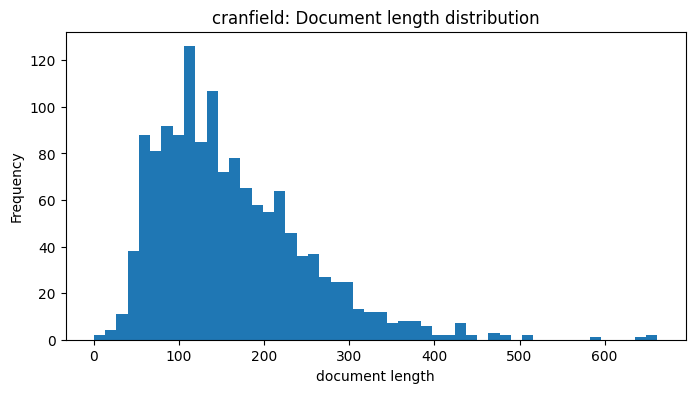

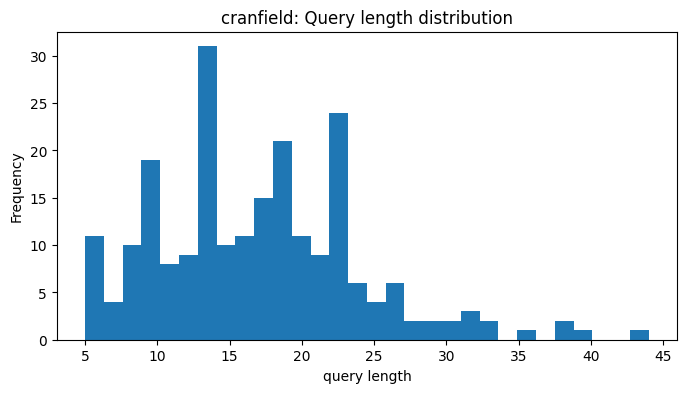

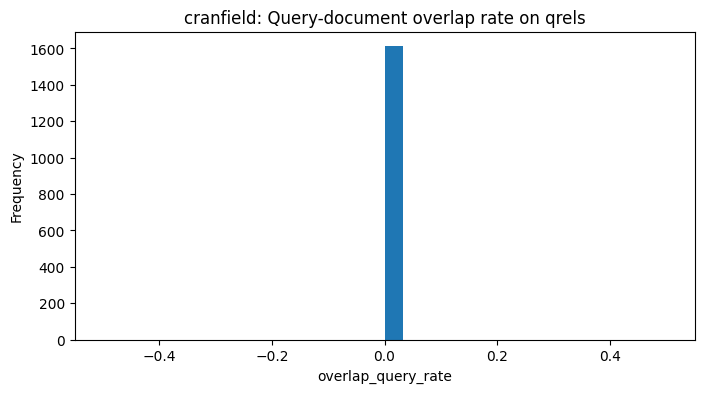

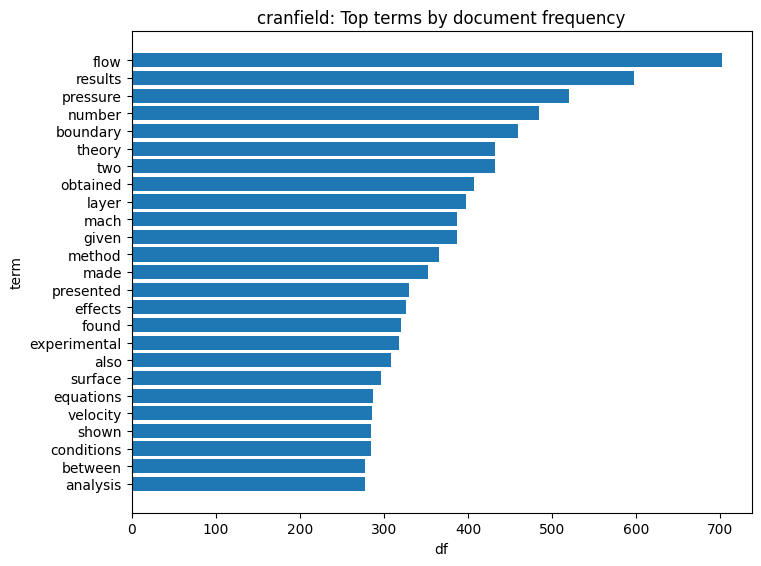

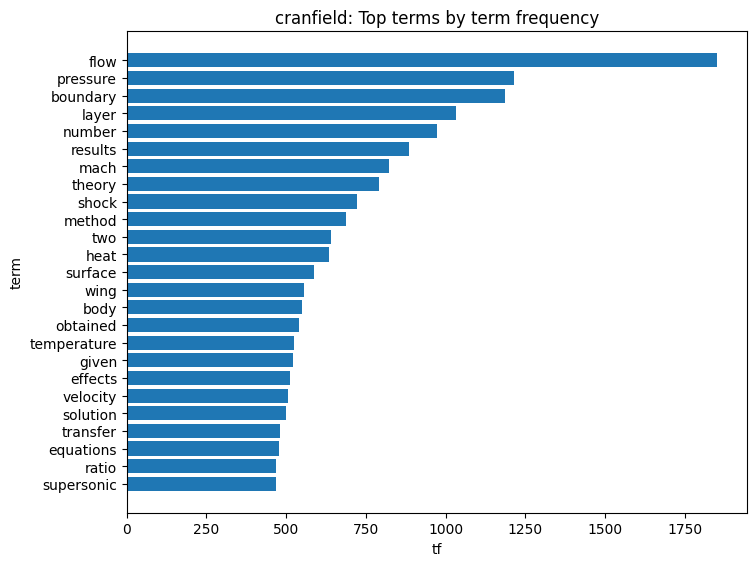

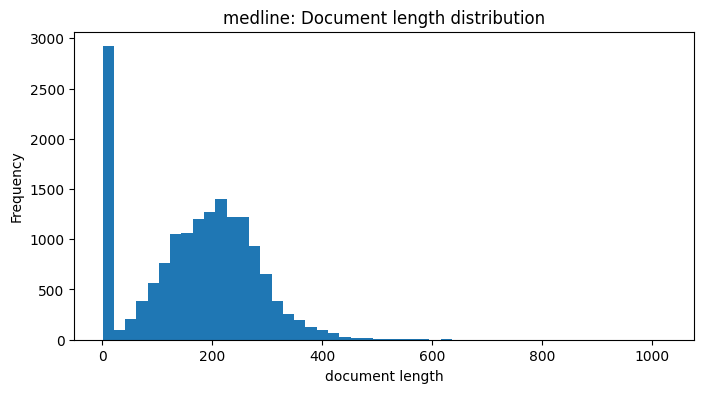

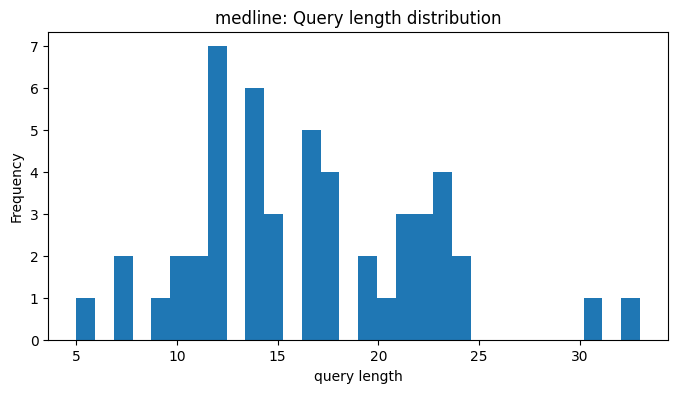

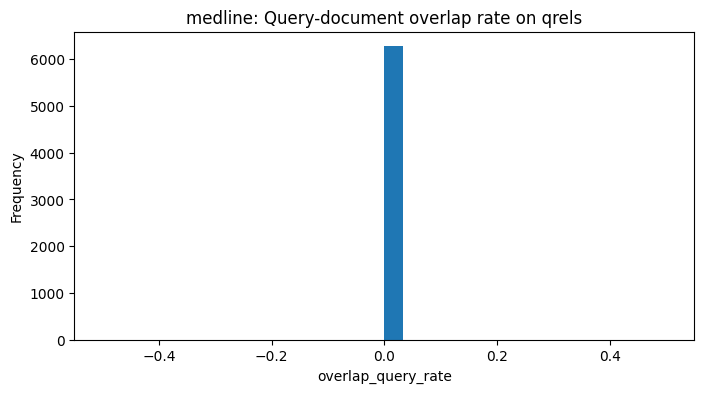

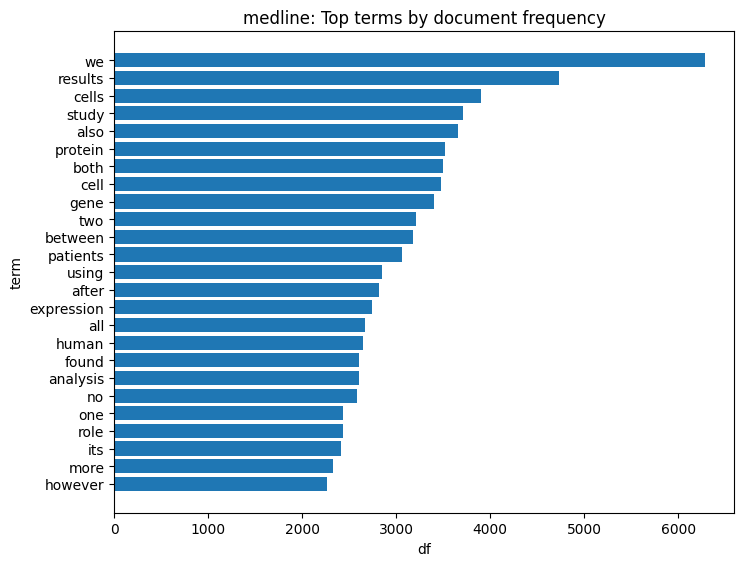

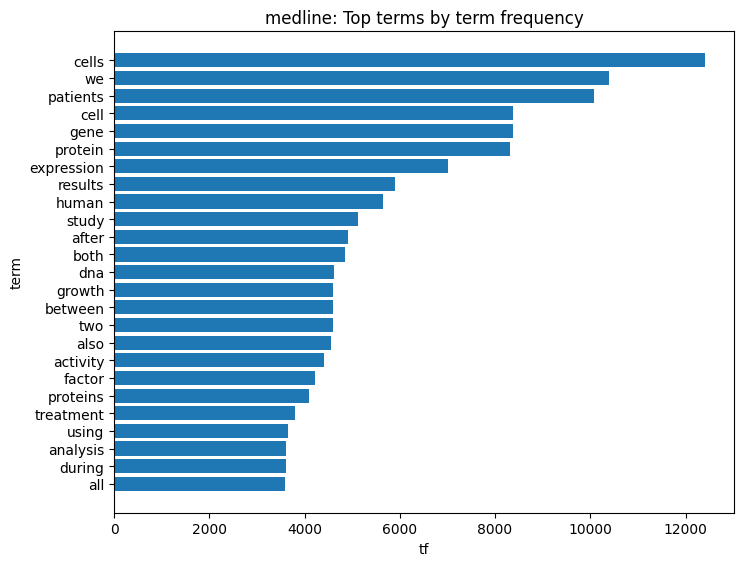

In [67]:
for name, corpus in corpora.items():
    docs = corpus["docs"]
    queries = corpus["queries"]
    term_df = term_stats[name]
    overlap_df = overlap_stats[name]
    
    plot_distribution(docs["doc_length"], f"{name}: Document length distribution", "document length", bins=50)
    plot_distribution(queries["query_length"], f"{name}: Query length distribution", "query length", bins=30)
    plot_distribution(overlap_df["overlap_query_rate"], f"{name}: Query-document overlap rate on qrels", "overlap_query_rate", bins=30)
    plot_top_terms(term_df, "df", f"{name}: Top terms by document frequency", top_n=25)
    plot_top_terms(term_df, "tf", f"{name}: Top terms by term frequency", top_n=25)

## 5. Comparison: Cranfield vs MEDLINE

Phần này so sánh trực tiếp hai corpus theo các nhóm đặc trưng chính.

In [68]:
summary_df = pd.DataFrame(summaries).set_index("corpus")
summary_df.T

corpus,cranfield,medline
n_docs,1400.000000,16216.000000
n_queries,225.000000,50.000000
n_qrels,1611.000000,6274.000000
n_relevant_pairs,1611.000000,6274.000000
vocab_size_docs,7488.000000,85401.000000
vocab_size_queries,977.000000,331.000000
query_terms_in_doc_vocab_rate,0.855681,0.885196
empty_docs,2.000000,0.000000
empty_queries,0.000000,0.000000
duplicate_doc_texts,1.000000,13.000000


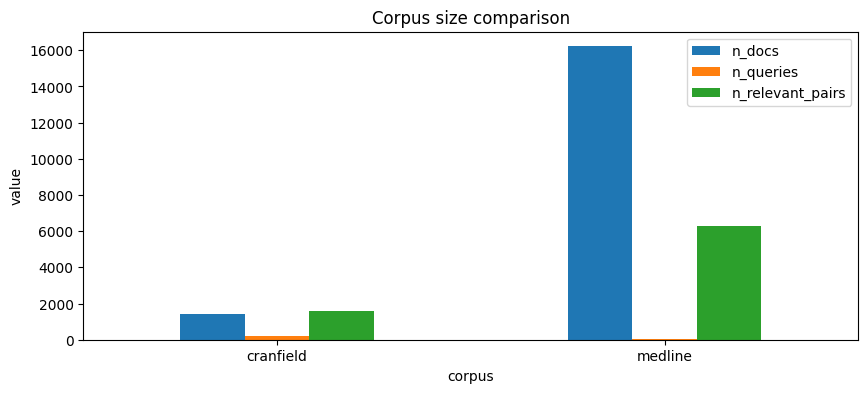

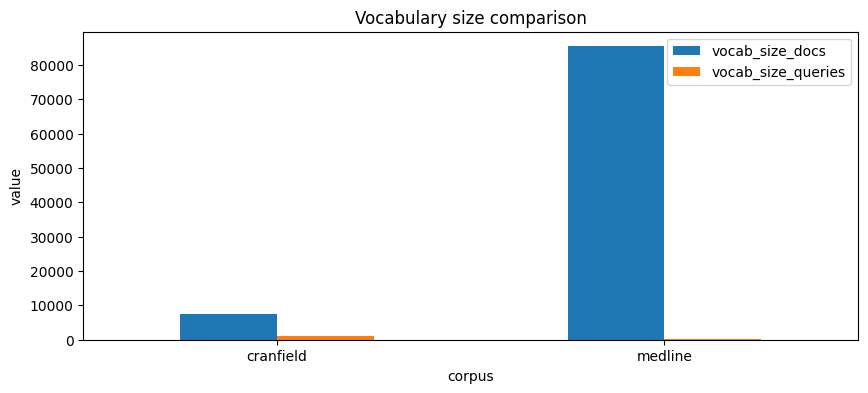

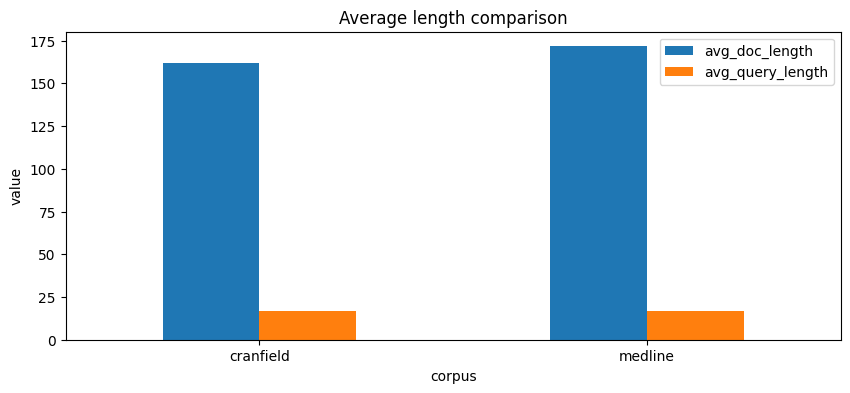

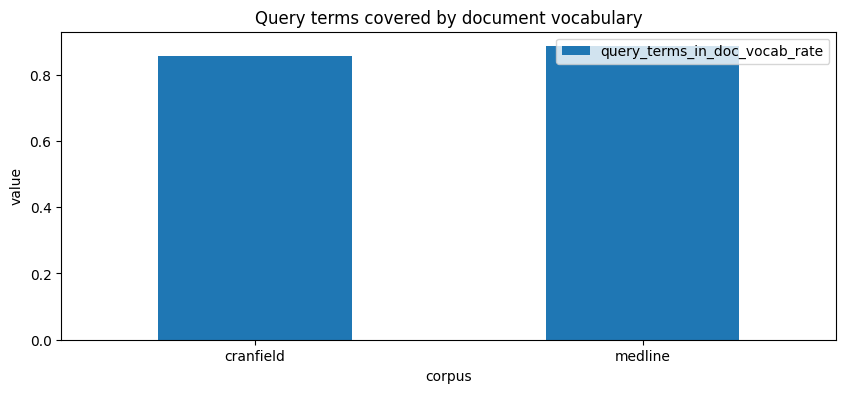

In [69]:
def comparison_bar(summary_df, columns, title):
    data = summary_df[columns]
    ax = data.plot(kind="bar", figsize=(10, 4))
    ax.set_title(title)
    ax.set_ylabel("value")
    plt.xticks(rotation=0)
    plt.show()

comparison_bar(summary_df, ["n_docs", "n_queries", "n_relevant_pairs"], "Corpus size comparison")
comparison_bar(summary_df, ["vocab_size_docs", "vocab_size_queries"], "Vocabulary size comparison")
comparison_bar(summary_df, ["avg_doc_length", "avg_query_length"], "Average length comparison")
comparison_bar(summary_df, ["query_terms_in_doc_vocab_rate"], "Query terms covered by document vocabulary")

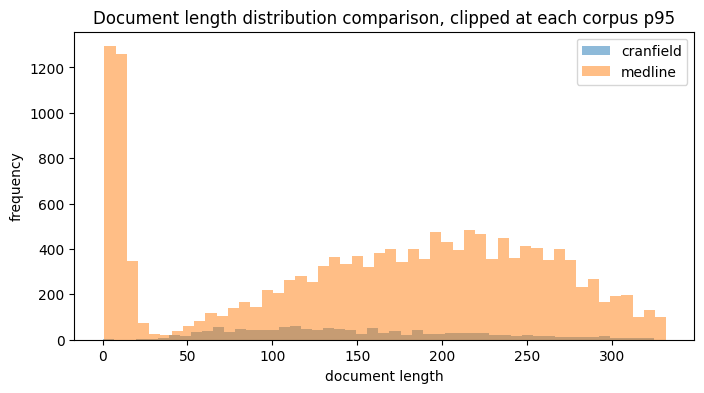

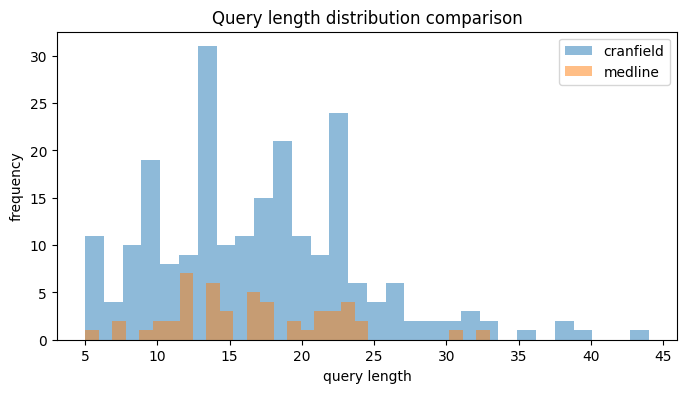

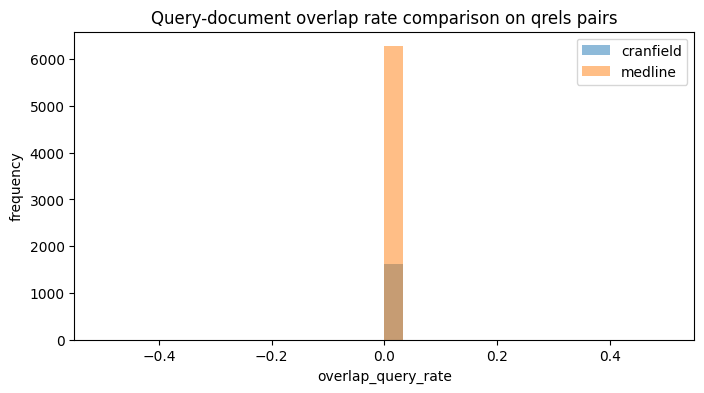

In [70]:
# Distribution comparison: document length
plt.figure(figsize=(8, 4))
for name, corpus in corpora.items():
    values = corpus["docs"]["doc_length"].dropna()
    # Clip at p95 for readability when corpus has long-tail documents.
    upper = values.quantile(0.95)
    plt.hist(values[values <= upper], bins=50, alpha=0.5, label=name)
plt.title("Document length distribution comparison, clipped at each corpus p95")
plt.xlabel("document length")
plt.ylabel("frequency")
plt.legend()
plt.show()

# Distribution comparison: query length
plt.figure(figsize=(8, 4))
for name, corpus in corpora.items():
    values = corpus["queries"]["query_length"].dropna()
    plt.hist(values, bins=30, alpha=0.5, label=name)
plt.title("Query length distribution comparison")
plt.xlabel("query length")
plt.ylabel("frequency")
plt.legend()
plt.show()

# Distribution comparison: overlap rate
plt.figure(figsize=(8, 4))
for name, overlap_df in overlap_stats.items():
    plt.hist(overlap_df["overlap_query_rate"].dropna(), bins=30, alpha=0.5, label=name)
plt.title("Query-document overlap rate comparison on qrels pairs")
plt.xlabel("overlap_query_rate")
plt.ylabel("frequency")
plt.legend()
plt.show()

## 6. Term-level Comparison

Phần này giúp trả lời câu hỏi: hai corpus khác nhau như thế nào về term distribution?

Các phân tích gồm:

- overlap vocabulary giữa hai corpus,
- top terms riêng từng corpus,
- IDF distribution,
- tỷ lệ query terms không có trong document vocabulary.

In [71]:
if set(corpora.keys()) >= {"cranfield", "medline"}:
    cran_terms = set(term_stats["cranfield"]["term"])
    med_terms = set(term_stats["medline"]["term"])
    shared_terms = cran_terms & med_terms
    union_terms = cran_terms | med_terms
    
    vocab_comparison = pd.DataFrame([
        {"metric": "cranfield_vocab", "value": len(cran_terms)},
        {"metric": "medline_vocab", "value": len(med_terms)},
        {"metric": "shared_vocab", "value": len(shared_terms)},
        {"metric": "union_vocab", "value": len(union_terms)},
        {"metric": "jaccard_vocab", "value": safe_divide(len(shared_terms), len(union_terms))},
        {"metric": "cranfield_vocab_shared_rate", "value": safe_divide(len(shared_terms), len(cran_terms))},
        {"metric": "medline_vocab_shared_rate", "value": safe_divide(len(shared_terms), len(med_terms))},
    ])
    display(vocab_comparison)
else:
    print("Vocabulary comparison expects corpus names: cranfield and medline")

,metric,value
0,cranfield_vocab,7488.000000
1,medline_vocab,85401.000000
2,shared_vocab,5624.000000
3,union_vocab,87265.000000
4,jaccard_vocab,0.064447
5,cranfield_vocab_shared_rate,0.751068
6,medline_vocab_shared_rate,0.065854


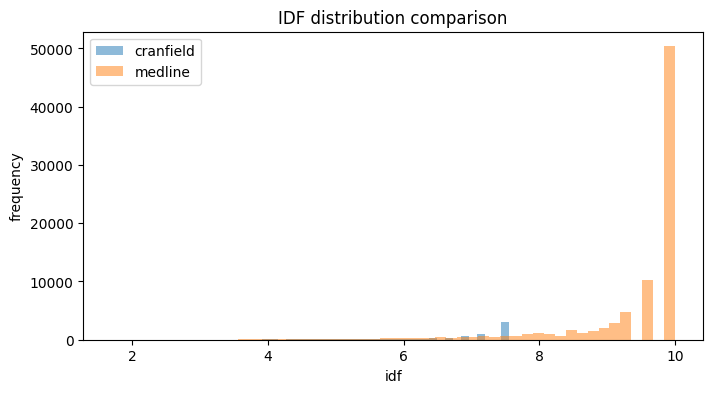

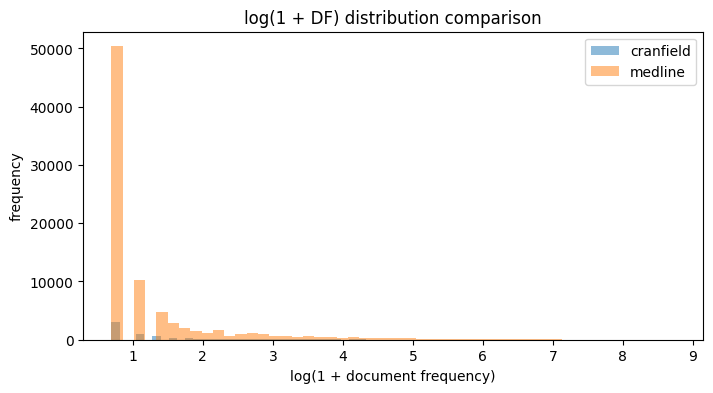

In [72]:
# IDF distribution comparison
plt.figure(figsize=(8, 4))
for name, term_df in term_stats.items():
    plt.hist(term_df["idf"].dropna(), bins=50, alpha=0.5, label=name)
plt.title("IDF distribution comparison")
plt.xlabel("idf")
plt.ylabel("frequency")
plt.legend()
plt.show()

# DF distribution comparison, log scale on x for readability
plt.figure(figsize=(8, 4))
for name, term_df in term_stats.items():
    df_values = term_df["df"].dropna()
    plt.hist(np.log1p(df_values), bins=50, alpha=0.5, label=name)
plt.title("log(1 + DF) distribution comparison")
plt.xlabel("log(1 + document frequency)")
plt.ylabel("frequency")
plt.legend()
plt.show()

## 7. Relevance Structure Comparison

Phần này quan trọng vì retrieval difficulty không chỉ phụ thuộc vào văn bản, mà còn phụ thuộc vào qrels:

- mỗi query có bao nhiêu relevant documents,
- relevance có binary hay graded không,
- có query nào không có relevant document không.

In [73]:
relevance_summaries = []

for name, corpus in corpora.items():
    qrels = corpus["qrels"]
    queries = corpus["queries"]
    relevant_qrels = qrels[qrels["_relevance"] > 0]
    rel_per_query = relevant_qrels.groupby("_query_id")["_doc_id"].nunique()
    all_query_ids = set(queries["_query_id"])
    query_ids_with_rel = set(rel_per_query.index)
    relevance_values = sorted(qrels["_relevance"].dropna().unique().tolist())
    
    relevance_summaries.append({
        "corpus": name,
        "n_queries": len(all_query_ids),
        "queries_with_relevance": len(query_ids_with_rel),
        "queries_without_relevance": len(all_query_ids - query_ids_with_rel),
        "avg_relevant_docs_per_query_with_rel": rel_per_query.mean(),
        "median_relevant_docs_per_query_with_rel": rel_per_query.median(),
        "max_relevant_docs_per_query": rel_per_query.max(),
        "relevance_values": relevance_values,
        "is_binary_relevance": set(relevance_values).issubset({0, 1}),
    })

relevance_summary_df = pd.DataFrame(relevance_summaries).set_index("corpus")
relevance_summary_df.T

corpus,cranfield,medline
n_queries,225,50
queries_with_relevance,225,50
queries_without_relevance,0,0
avg_relevant_docs_per_query_with_rel,7.16,125.48
median_relevant_docs_per_query_with_rel,6.0,85.0
max_relevant_docs_per_query,39,566
relevance_values,"[1, 2, 3, 4]","[1, 2]"
is_binary_relevance,False,False


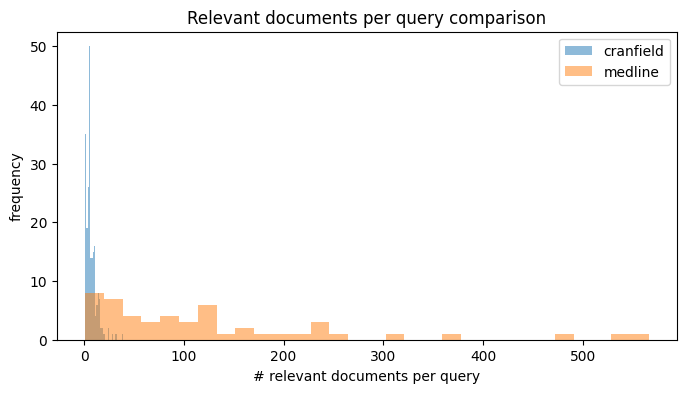

In [74]:
plt.figure(figsize=(8, 4))
for name, corpus in corpora.items():
    relevant_qrels = corpus["qrels"][corpus["qrels"]["_relevance"] > 0]
    rel_per_query = relevant_qrels.groupby("_query_id")["_doc_id"].nunique()
    plt.hist(rel_per_query.dropna(), bins=30, alpha=0.5, label=name)
plt.title("Relevant documents per query comparison")
plt.xlabel("# relevant documents per query")
plt.ylabel("frequency")
plt.legend()
plt.show()

## 8. Query Difficulty Proxy

Ở giai đoạn corpus analysis, chưa cần chạy mô hình retrieval. Nhưng ta có thể tạo một vài proxy cho độ khó của query:

- query length,
- tỷ lệ query terms nằm trong document vocabulary,
- IDF trung bình của query terms,
- overlap trung bình trên relevant docs.

Các proxy này có thể dùng sau này để giải thích vì sao một mô hình fail hoặc outperform ở một nhóm query cụ thể.

In [75]:
def compute_query_difficulty_proxy(corpus, term_df, overlap_df):
    queries = corpus["queries"]
    idf_map = term_df.set_index("term")["idf"].to_dict()
    doc_vocab = set(term_df["term"])
    
    rows = []
    for _, row in queries.iterrows():
        qid = row["_query_id"]
        tokens = row["tokens"]
        unique_tokens = set(tokens)

        covered = unique_tokens & doc_vocab
        idfs = [idf_map[t] for t in unique_tokens if t in idf_map]

        rel_overlap = overlap_df[
            (overlap_df["query_id"] == qid) &
            (overlap_df["relevance"] > 0)
        ]

        rows.append({
            "query_id": qid,
            "query_length": len(tokens),
            "unique_query_terms": len(unique_tokens),
            "query_vocab_coverage_rate": safe_divide(len(covered), len(unique_tokens)),
            "mean_query_idf": np.mean(idfs) if idfs else np.nan,
            "max_query_idf": np.max(idfs) if idfs else np.nan,
            "mean_overlap_on_relevant_docs": rel_overlap["overlap_query_rate"].mean() if len(rel_overlap) else np.nan,
            "n_relevant_docs": len(rel_overlap),
        })

    return pd.DataFrame(rows)

query_difficulty = {}
for name in corpora:
    query_difficulty[name] = compute_query_difficulty_proxy(corpora[name], term_stats[name], overlap_stats[name])
    print(f"\n{name.upper()} query difficulty proxy")
    display(query_difficulty[name].describe())


CRANFIELD query difficulty proxy


,query_length,unique_query_terms,query_vocab_coverage_rate,mean_query_idf,max_query_idf,mean_overlap_on_relevant_docs,n_relevant_docs
count,225.000000,225.000000,225.000000,225.000000,225.000000,0.0,225.0
mean,16.973333,15.551111,0.621133,4.005608,5.910618,NaN,0.0
std,7.092451,5.807039,0.106185,0.519651,0.950426,NaN,0.0
min,5.000000,5.000000,0.333333,2.737467,3.629821,NaN,0.0
25%,12.000000,12.000000,0.555556,3.676249,5.300503,NaN,0.0
50%,16.000000,15.000000,0.615385,3.961154,5.942356,NaN,0.0
75%,21.000000,19.000000,0.666667,4.354256,6.635504,NaN,0.0
max,44.000000,36.000000,1.000000,5.807747,7.551794,NaN,0.0



MEDLINE query difficulty proxy


,query_length,unique_query_terms,query_vocab_coverage_rate,mean_query_idf,max_query_idf,mean_overlap_on_relevant_docs,n_relevant_docs
count,50.000000,50.000000,50.000000,50.000000,50.000000,0.0,50.0
mean,16.620000,12.800000,0.696010,4.999163,7.570351,NaN,0.0
std,5.802498,4.356557,0.112159,0.612032,1.405615,NaN,0.0
min,5.000000,4.000000,0.428571,3.772501,5.013643,NaN,0.0
25%,12.000000,10.000000,0.600000,4.410512,6.601698,NaN,0.0
50%,17.000000,12.500000,0.692308,5.113448,7.418275,NaN,0.0
75%,21.000000,15.000000,0.764423,5.443152,8.367403,NaN,0.0
max,33.000000,26.000000,1.000000,6.701631,10.000668,NaN,0.0


## 9. Export Analysis Tables

Cell này lưu các bảng phân tích quan trọng ra CSV để dùng cho report hoặc LaTeX.

In [76]:
OUTPUT_DIR = Path("corpus_analysis_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(OUTPUT_DIR / "corpus_summary.csv")
relevance_summary_df.to_csv(OUTPUT_DIR / "relevance_summary.csv")

for name in corpora:
    term_stats[name].to_csv(OUTPUT_DIR / f"{name}_term_statistics.csv", index=False)
    overlap_stats[name].to_csv(OUTPUT_DIR / f"{name}_query_doc_overlap.csv", index=False)
    # query_difficulty may be empty if proxies were not computed; guard access to avoid KeyError
    if name in query_difficulty and query_difficulty[name] is not None and not query_difficulty[name].empty:
        query_difficulty[name].to_csv(OUTPUT_DIR / f"{name}_query_difficulty_proxy.csv", index=False)

print(f"Saved outputs to: {OUTPUT_DIR.resolve()}")

Saved outputs to: C:\Users\ADMIN\Documents\Nam_3\CS419\project\corpus_analysis\corpus_analysis_outputs


## 10. Interpretation Template

Sau khi chạy notebook, bạn có thể viết phần nhận xét theo cấu trúc sau:

### Cranfield

- Corpus có bao nhiêu documents, queries, qrels?
- Document/query length phân phối như thế nào?
- Vocabulary có nhỏ hay lớn?
- Query terms có được cover tốt bởi document vocabulary không?
- Mỗi query có nhiều hay ít relevant documents?

### MEDLINE

- Corpus lớn hơn Cranfield ở mức nào?
- Vocabulary có sparse hơn không?
- Có nhiều term chuyên ngành, rare terms, hoặc long-tail không?
- Query-document overlap có thấp hơn không?
- Relevance structure có lệch hơn không?

### Comparison

- Corpus nào có khả năng thuận lợi hơn cho exact lexical matching?
- Corpus nào có thể gây khó cho TF-IDF/BM25 vì term sparsity hoặc domain vocabulary?
- Corpus nào có khả năng khiến LSA hữu ích hơn do latent semantic matching?
- Nếu MEDLINE có biomedical vocabulary chuyên ngành, mô hình nào có thể nhạy với rare terms nhất?

### Link sang phase model comparison

Các thống kê này sẽ được dùng để giải thích kết quả của:

- Precision@k,
- Recall@k,
- F1@k,
- MAP@k,
- NDCG@k.